# Gantt Chart in Python

## Learning objectives

By the end of the activity, You should be able to:

1. Explain what a **Gantt chart** represents.
2. Represent project tasks using start dates, end dates, and durations.
3. Convert dates into values that Matplotlib can position on an axis.
4. Build a horizontal timeline using Python.
5. Improve chart readability using labels, ordering, grid lines, and date formatting.
6. Interpret the project schedule rather than simply display it.


## 1. What is a Gantt chart?

A **Gantt chart** is a project-management visualisation that shows **when activities take place and how long they last**.

Typically:

- the **vertical axis** contains tasks or project activities;
- the **horizontal axis** represents time;
- each horizontal bar represents the duration of one task;
- the left edge of a bar represents its **start date**;
- the right edge represents its **end date**.

### Before coding

Suppose a task starts on 5 March and ends on 15 March.

**Question:** What information does Python need in order to draw that task as a horizontal bar?

Think about:

- where the bar should start;
- how wide it should be;
- where its label should appear.


## Next step

Run the code and identify what changes in either the data or the visualisation.

Try to explain the purpose of the cell in one sentence before looking at its output.


In [1]:
pip install plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 182.0 kB/s  0:00:47 eta 0:00:02
Note: you may need to restart the kernel to use updated packages.


## 2. Import the required libraries

We begin by importing the tools needed for data handling and visualisation.

As you read the imports, ask:

- Which library handles tabular project data?
- Which library draws the chart?
- Which module helps Matplotlib work with dates?

Understanding imports makes the later code easier to follow.


In [1]:
import plotly.express as px
import pandas as pd
import nbformat

df = pd.DataFrame([
    dict (Item="Job R", Start='2009-01-01', Finish='2009-02-28'),
    dict (Item="Job S", Start='2009-03-05', Finish='2009-04-15'),
    dict (Item="Job T", Start='2009-02-20', Finish='2009-05-30')
])

fig = px.timeline (df, x_start="Start", x_end="Finish", y="Item")
fig.update_yaxes (autorange="reversed")
fig.show()


## 3. Define the project schedule

A Gantt chart begins with structured project data.

Each task should ideally contain:

- **Task name**
- **Start date**
- **End date**

From the start and end dates we can calculate **duration**.

> Why is storing the schedule in a DataFrame preferable to manually drawing every bar?


In [2]:
df = pd.DataFrame([
    dict (Item="Job R", Start='2009-01-01', Finish='2009-02-28', Resource="Stuart"),
    dict (Item="Job S", Start='2009-03-05', Finish='2009-04-15', Resource="Stuart"),
    dict (Item="Job T", Start='2009-02-20', Finish='2009-05-30', Resource="Mary")
])

fig = px.timeline (df, x_start="Start", x_end="Finish", y="Item", color="Resource")
fig.update_yaxes (autorange="reversed")
fig.show()


## 3. Define the project schedule

A Gantt chart begins with structured project data.

Each task should ideally contain:

- **Task name**
- **Start date**
- **End date**

From the start and end dates we can calculate **duration**.

> Why is storing the schedule in a DataFrame preferable to manually drawing every bar?


In [3]:
df = pd.DataFrame([
    dict (Item="Job R", Start='2009-01-01', Finish='2009-02-28', Completion_pct=40),
    dict (Item="Job S", Start='2009-03-05', Finish='2009-04-15', Completion_pct=35),
    dict (Item="Job T", Start='2009-02-20', Finish='2009-05-30', Completion_pct=25)
])

fig = px.timeline (df, x_start="Start", x_end="Finish", y="Item", color="Completion_pct")
fig.update_yaxes (autorange="reversed")
fig.show()


## 2. Import the required libraries

We begin by importing the tools needed for data handling and visualisation.

As you read the imports, ask:

- Which library handles tabular project data?
- Which library draws the chart?
- Which module helps Matplotlib work with dates?

Understanding imports makes the later code easier to follow.


In [7]:
import plotly.express as px

df = pd.DataFrame([
    dict(Task="Job-R", Start="2017-01-01", Finish="2017-02-02",
         Resource="Finished"),
    dict(Task="Job-R", Start="2017-02-15", Finish="2017-03-15",
         Resource="Unfinished"),
    dict(Task="Job-S", Start="2017-01-17", Finish="2017-02-17",
         Resource="Finished"),
    dict(Task="Job-S", Start="2017-02-25", Finish="2017-03-28",
         Resource="Yet to Begin")
])

fig = px.timeline(
    df,
    x_start="Start",
    x_end="Finish",
    y="Task",
    color="Resource",
    title="Project Status Gantt Chart"
)

# Put the first task at the top
fig.update_yaxes(autorange="reversed")

fig.update_layout(
    xaxis_title="Project Timeline",
    yaxis_title="Task",
    legend_title="Status",
    height=450
)

fig.show()

# 7. A cleaner, presentation-ready Gantt chart

The original plot demonstrates the core idea. We can now improve the chart for communication.

- identifies the schedule DataFrame created earlier;
- detects task/start/end columns where possible;
- calculates duration;
- sorts tasks by start date;
- uses a horizontal bar chart;
- formats the x-axis as calendar dates;
- adds start/end labels;
- uses subtle grid lines;
- avoids unnecessary chart decoration.

The objective is **clarity**, not simply adding more visual elements.


In [8]:
# Find the main DataFrame created in the original activity.
dataframes = {
    name: obj for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

if not dataframes:
    raise ValueError("No DataFrame found. Run the original activity cells first.")

schedule = max(dataframes.values(), key=lambda x: x.shape[0] * x.shape[1]).copy()

print("Available columns:", schedule.columns.tolist())
display(schedule.head())


Available columns: ['Task', 'Start', 'Finish', 'Resource']


,Task,Start,Finish,Resource
0,Job-R,2017-01-01,2017-02-02,Finished
1,Job-R,2017-02-15,2017-03-15,Unfinished
2,Job-S,2017-01-17,2017-02-17,Finished
3,Job-S,2017-02-25,2017-03-28,Yet to Begin


## 8. Prepare the schedule safely

Column names vary between activities, so this cell searches for likely task, start-date, and end-date columns.

This also demonstrates a useful programming principle:

> Separate **data preparation** from **visualisation**.

That makes the code easier to debug, explain, and reuse.


In [9]:
# Identify likely columns from their names.
def find_column(columns, keywords):
    for column in columns:
        name = str(column).lower().replace("_", " ")
        if any(keyword in name for keyword in keywords):
            return column
    return None

task_col = find_column(schedule.columns, ["task", "activity", "phase", "name"])
start_col = find_column(schedule.columns, ["start", "begin"])
end_col = find_column(schedule.columns, ["end", "finish", "complete"])

print("Task column :", task_col)
print("Start column:", start_col)
print("End column  :", end_col)

if task_col is None or start_col is None or end_col is None:
    raise ValueError(
        "Could not automatically identify Task, Start, and End columns. "
        "Set task_col, start_col, and end_col manually using the column names printed above."
    )

schedule[start_col] = pd.to_datetime(schedule[start_col])
schedule[end_col] = pd.to_datetime(schedule[end_col])

schedule["Duration_days"] = (schedule[end_col] - schedule[start_col]).dt.days

# Sort by start date so the schedule has a logical reading order.
schedule = schedule.sort_values(start_col).reset_index(drop=True)

display(schedule[[task_col, start_col, end_col, "Duration_days"]])


Task column : Task
Start column: Start
End column  : Finish


,Task,Start,Finish,Duration_days
0,Job-R,2017-01-01,2017-02-02,32
1,Job-S,2017-01-17,2017-02-17,31
2,Job-R,2017-02-15,2017-03-15,28
3,Job-S,2017-02-25,2017-03-28,31


### Data-quality checkpoint

Before plotting, check the duration column.

A **negative duration** would mean an end date occurs before its start date and would indicate a scheduling or data-entry problem.

A duration of **zero days** may represent a milestone rather than a normal task.

This is a good example of how a calculated feature can reveal data-quality issues.


In [10]:
invalid = schedule[schedule["Duration_days"] < 0]

if invalid.empty:
    print("✓ No negative task durations were found.")
else:
    print("Warning: tasks with end dates before their start dates:")
    display(invalid[[task_col, start_col, end_col, "Duration_days"]])


✓ No negative task durations were found.


# 9. Improved Gantt chart

Instead of treating dates as arbitrary numbers, the x-axis is formatted explicitly as a timeline.

The task bars communicate duration, while the labels make the exact date range available without forcing the reader to estimate everything from the axis.


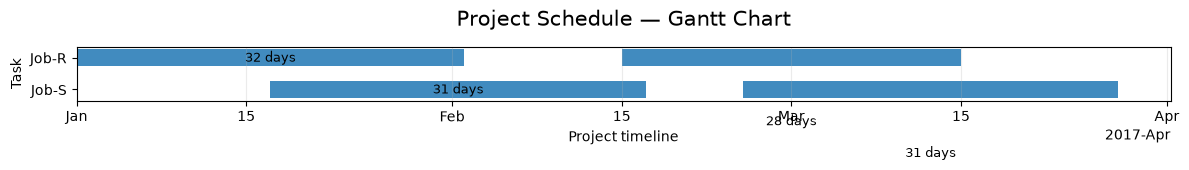

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, max(5, len(schedule) * 0.65)))

# Matplotlib can position datetime values directly.
ax.barh(
    schedule[task_col],
    schedule["Duration_days"],
    left=schedule[start_col],
    height=0.55,
    alpha=0.85
)

# Put the earliest task near the top.
ax.invert_yaxis()

# Format the timeline.
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.set_title("Project Schedule — Gantt Chart", fontsize=15, pad=15)
ax.set_xlabel("Project timeline")
ax.set_ylabel("Task")

# A light x-grid helps readers compare dates without dominating the chart.
ax.grid(axis="x", alpha=0.25)

# Add compact duration labels to the bars.
for y, row in schedule.iterrows():
    midpoint = row[start_col] + (row[end_col] - row[start_col]) / 2
    ax.text(
        midpoint,
        y,
        f'{row["Duration_days"]} days',
        ha="center",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## 10. How to interpret the improved chart

A strong interpretation goes beyond saying that one bar is longer than another.

Use the following structure:

### A. Timing
Which tasks start first and which finish last?

### B. Duration
Which tasks occupy the greatest amount of project time?

### C. Overlap
Which tasks happen simultaneously?

Overlap may indicate:

- parallel work;
- shared-resource pressure;
- dependencies that need closer examination.

### D. Gaps
Are there periods where no activity appears to be scheduled?

### E. Project management meaning
Does the schedule appear mostly sequential or parallel?

> **Important limitation:** A basic Gantt chart shows the schedule, but it does not automatically prove which task is on the **critical path**. Critical-path analysis requires dependency information.


# 11. Challenge

Modify the project schedule and answer the following questions.

### Task A
Add another task with its own start and end date.

### Task B 
Change one start date so that two activities run simultaneously.

What changes visually?

### Task C
Move one activity five days later.

Does this automatically delay the whole project? Why might dependency information be needed to answer that question?

### Task D
Use Python rather than visually guessing.

**Hint:**

`Duration_days` contains the information you need.


In [12]:
# Example analytical questions students can answer programmatically.

if 'schedule' in globals():
    longest = schedule.loc[schedule["Duration_days"].idxmax()]

    print("Longest scheduled task")
    print("----------------------")
    print(f"Task:     {longest[task_col]}")
    print(f"Start:    {longest[start_col].date()}")
    print(f"End:      {longest[end_col].date()}")
    print(f"Duration: {longest['Duration_days']} days")

    project_start = schedule[start_col].min()
    project_end = schedule[end_col].max()

    print("\nOverall project window")
    print("----------------------")
    print(f"Start: {project_start.date()}")
    print(f"End:   {project_end.date()}")
    print(f"Calendar span: {(project_end - project_start).days} days")


Longest scheduled task
----------------------
Task:     Job-R
Start:    2017-01-01
End:      2017-02-02
Duration: 32 days

Overall project window
----------------------
Start: 2017-01-01
End:   2017-03-28
Calendar span: 86 days


# 12. Key takeaways

After completing this activity, you should understand that a Gantt chart combines **data processing and data visualisation**.

The important ideas are:

- Dates should be stored as datetime values.
- `End − Start` gives task duration.
- In a horizontal Gantt chart, the start date controls the **position** of a bar.
- Duration controls the **width** of a bar.
- Sorting tasks makes the timeline easier to read.
- Labels and date formatting improve communication.
- Overlapping bars reveal concurrent activities.
- A Gantt chart is a **schedule visualisation**, not automatically a dependency or critical-path analysis.

### Exit question

> **Why is a Gantt chart more useful than a simple table of project start and end dates?**
